AI Session 28 start @
EDA
Explore the data and understand and summarize the data before building the any model
Input file
C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/flight_price.xlsx

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


It looks like you're running into a common issue when trying to read Excel files in a Colab or Jupyter environment. Even though you have pandas imported, the read_excel function requires a specific engine (like openpyxl) to handle .xlsx files.

Since you are working in a Google Colab environment (as seen in your shared page Flight_ticket_EDA_with_RegressionModels.ipynb), you can fix this by installing the library directly in a code cell.

How to Fix the Error
Add a new code cell at the very top of your notebook.

Run the following command:

Python
!pip install openpyxl
Restart the Runtime (optional but recommended): Go to Runtime -> Restart session.

Re-run your code:

Python
df = pd.read_excel("flight_price.xlsx")

Gemini
A Quick Note on File Paths
In your notebook, you are currently using a local Windows path:
df=pd.read_excel("C://Users//kumar//Desktop//flight_price.xlsx")

Note: Because Colab runs on Google's cloud servers, it cannot "see" your computer's C:// drive. To make this work in Colab, you should:

Click the Folder icon on the left sidebar.

Upload your flight_price.xlsx file there.

Change your code to: df = pd.read_excel("flight_price.xlsx").

Would you like me to show you how to mount your Google Drive instead so you don't have to upload the file every time you open the notebook?

In [5]:
df=pd.read_excel("C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/flight_price.xlsx")

In [6]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [8]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [9]:
df.describe()#a basic statistics on numeric column

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [11]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

Feature engineering:
Process of creating,transforming ,selecting input features.
dt is some variable

In [14]:
df["Journey_Day"]=pd.to_datetime(df["Date_of_Journey"],format=("%d/%m/%Y")).dt.day

In [15]:
df["Journey_Month"]=pd.to_datetime(df["Date_of_Journey"],format=("%d/%m/%Y")).dt.month

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Date_of_Journey  10682 non-null  str  
 2   Source           10682 non-null  str  
 3   Destination      10682 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10682 non-null  str  
 6   Arrival_Time     10682 non-null  str  
 7   Duration         10682 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10682 non-null  str  
 10  Price            10682 non-null  int64
 11  Journey_Day      10682 non-null  int32
 12  Journey_Month    10682 non-null  int32
dtypes: int32(2), int64(1), str(10)
memory usage: 1.1 MB


In [17]:
df['Journey_Day']

0        24
1         1
2         9
3        12
4         1
         ..
10678     9
10679    27
10680    27
10681     1
10682     9
Name: Journey_Day, Length: 10682, dtype: int32

In [18]:
df['Journey_Month']

0        3
1        5
2        6
3        5
4        3
        ..
10678    4
10679    4
10680    4
10681    3
10682    5
Name: Journey_Month, Length: 10682, dtype: int32

axis->0 ->vertical direction-->rows 
axis->1 ->horizontal direction-->columns

In [109]:
df1=pd.DataFrame([[1,4,7],[2,5,8],[6,7,8]])

In [110]:
df1

,0,1,2
0,1,4,7
1,2,5,8
2,6,7,8


In [ ]:
df1.sum(axis=0)# Verticale operation, there operation go down the rows

0     9
1    16
2    23
dtype: int64

In [ ]:
df1.sum(axis=1)#operation goed across the columns

0    12
1    15
2    21
dtype: int64

In [115]:
df1

,0,1,2
0,1,4,7
1,2,5,8
2,6,7,8


In [116]:
df1.drop(2,axis=0) #This will remove last raw

,0,1,2
0,1,4,7
1,2,5,8


In [ ]:
df1.drop(2,axis=1) #This will remove last column

,0,1
0,1,4
1,2,5
2,6,7


In [20]:
df.drop(["Date_of_Journey"],axis=1,inplace=True)

df.drop(["Date_of_Journey"],inplace=True) #If we remove axis=1 will give error.

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Source           10682 non-null  str  
 2   Destination      10682 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10682 non-null  str  
 5   Arrival_Time     10682 non-null  str  
 6   Duration         10682 non-null  str  
 7   Total_Stops      10682 non-null  str  
 8   Additional_Info  10682 non-null  str  
 9   Price            10682 non-null  int64
 10  Journey_Day      10682 non-null  int32
 11  Journey_Month    10682 non-null  int32
dtypes: int32(2), int64(1), str(9)
memory usage: 1001.4 KB


In [22]:
df["Dept_Hour"]=pd.to_datetime(df["Dep_Time"]).dt.hour

C:\Users\jaiam\AppData\Local\Temp\ipykernel_38684\2011143655.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dept_Hour"]=pd.to_datetime(df["Dep_Time"]).dt.hour


In [23]:
df["Dept_Min"]=pd.to_datetime(df["Dep_Time"]).dt.minute

C:\Users\jaiam\AppData\Local\Temp\ipykernel_38684\544447038.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dept_Min"]=pd.to_datetime(df["Dep_Time"]).dt.minute


In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Source           10682 non-null  str  
 2   Destination      10682 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10682 non-null  str  
 5   Arrival_Time     10682 non-null  str  
 6   Duration         10682 non-null  str  
 7   Total_Stops      10682 non-null  str  
 8   Additional_Info  10682 non-null  str  
 9   Price            10682 non-null  int64
 10  Journey_Day      10682 non-null  int32
 11  Journey_Month    10682 non-null  int32
 12  Dept_Hour        10682 non-null  int32
 13  Dept_Min         10682 non-null  int32
dtypes: int32(4), int64(1), str(9)
memory usage: 1.1 MB


In [25]:
df["Dept_Hour"]

0        22
1         5
2         9
3        18
4        16
         ..
10678    19
10679    20
10680     8
10681    11
10682    10
Name: Dept_Hour, Length: 10682, dtype: int32

In [26]:
df["Dept_Min"]

0        20
1        50
2        25
3         5
4        50
         ..
10678    55
10679    45
10680    20
10681    30
10682    55
Name: Dept_Min, Length: 10682, dtype: int32

In [27]:
df["Duration_Hour"]=df["Duration"].str.extract('(\d+)h').fillna(0).astype(int)
df["Duration_mins"]=df["Duration"].str.extract('(\d+)m').fillna(0).astype(int)
df["Duration_Hour"]

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: Duration_Hour, Length: 10682, dtype: int64

In [28]:
df["Duration_mins"]

0        50
1        25
2         0
3        25
4        45
         ..
10678    30
10679    35
10680     0
10681    40
10682    20
Name: Duration_mins, Length: 10682, dtype: int64

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Source           10682 non-null  str  
 2   Destination      10682 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10682 non-null  str  
 5   Arrival_Time     10682 non-null  str  
 6   Duration         10682 non-null  str  
 7   Total_Stops      10682 non-null  str  
 8   Additional_Info  10682 non-null  str  
 9   Price            10682 non-null  int64
 10  Journey_Day      10682 non-null  int32
 11  Journey_Month    10682 non-null  int32
 12  Dept_Hour        10682 non-null  int32
 13  Dept_Min         10682 non-null  int32
 14  Duration_Hour    10682 non-null  int64
 15  Duration_mins    10682 non-null  int64
dtypes: int32(4), int64(3), str(9)
memory usage: 1.2 MB


In [ ]:
df['Total_Stops'].unique()#This will dispaly how many items we have for Stop

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [31]:
df["Total_Stops"]=df["Total_Stops"].map({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4})

In [32]:
df["Total_Stops"]

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

In [33]:
df["Additional_Info"].unique()

<StringArray>
[                     'No info',  'In-flight meal not included',
 'No check-in baggage included',              '1 Short layover',
                      'No Info',               '1 Long layover',
              'Change airports',               'Business class',
               'Red-eye flight',               '2 Long layover']
Length: 10, dtype: str

In [34]:
df["Airline"].unique()

<StringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple carriers Premium economy',                            'Trujet']
Length: 12, dtype: str

In [38]:
df["Source"].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [39]:
df["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

here we need to install scikit learn library-->It is MAchine learning library
pip install scikit-learn

Microsoft Windows [Version 10.0.26200.8117]
(c) Microsoft Corporation. All rights reserved.

C:\Users\jaiam>pip install scikit-learn
Requirement already satisfied: scikit-learn in c:\users\jaiam\appdata\local\programs\python\python311\lib\site-packages (1.7.0)
Requirement already satisfied: numpy>=1.22.0 in c:\users\jaiam\appdata\local\programs\python\python311\lib\site-packages (from scikit-learn) (2.3.0)
Requirement already satisfied: scipy>=1.8.0 in c:\users\jaiam\appdata\local\programs\python\python311\lib\site-packages (from scikit-learn) (1.15.3)
Requirement already satisfied: joblib>=1.2.0 in c:\users\jaiam\appdata\local\programs\python\python311\lib\site-packages (from scikit-learn) (1.5.1)
Requirement already satisfied: threadpoolctl>=3.1.0 in c:\users\jaiam\appdata\local\programs\python\python311\lib\site-packages (from scikit-learn) (3.6.0)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

C:\Users\jaiam>

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder=OneHotEncoder()#Create an Object

in below th fit_transform-->
fit--It learns unique categories transform-->converts them in to binary columns--0,1

In [43]:
encoder_df=pd.DataFrame(encoder.fit_transform(df[["Airline","Source","Destination"]]).toarray(),columns=encoder.get_feature_names_out(['Airline','Source','Destination']))

In [ ]:
encoder_df# Here we are putting transfer in to this data frame

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10678,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Source           10682 non-null  str  
 2   Destination      10682 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10682 non-null  str  
 5   Arrival_Time     10682 non-null  str  
 6   Duration         10682 non-null  str  
 7   Total_Stops      10682 non-null  int64
 8   Additional_Info  10682 non-null  str  
 9   Price            10682 non-null  int64
 10  Journey_Day      10682 non-null  int32
 11  Journey_Month    10682 non-null  int32
 12  Dept_Hour        10682 non-null  int32
 13  Dept_Min         10682 non-null  int32
 14  Duration_Hour    10682 non-null  int64
 15  Duration_mins    10682 non-null  int64
dtypes: int32(4), int64(4), str(8)
memory usage: 1.2 MB


Assigment 1: Try to do some visulizations on top of this.

In [47]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dept_Hour,Dept_Min,Duration_Hour,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,24,3,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,5,50,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,9,6,9,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,18,5,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,16,50,4,45


In [48]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Day',
       'Journey_Month', 'Dept_Hour', 'Dept_Min', 'Duration_Hour',
       'Duration_mins'],
      dtype='str')

In [49]:
df_numeric=df.drop(columns=["Airline","Source","Destination","Route","Dep_Time","Arrival_Time","Duration","Additional_Info"])

In [50]:
df_numeric

,Total_Stops,Price,Journey_Day,Journey_Month,Dept_Hour,Dept_Min,Duration_Hour,Duration_mins
0,0,3897,24,3,22,20,2,50
1,2,7662,1,5,5,50,7,25
2,2,13882,9,6,9,25,19,0
3,1,6218,12,5,18,5,5,25
4,1,13302,1,3,16,50,4,45
...,...,...,...,...,...,...,...,...
10678,0,4107,9,4,19,55,2,30
10679,0,4145,27,4,20,45,2,35
10680,0,7229,27,4,8,20,3,0
10681,0,12648,1,3,11,30,2,40


In [51]:
encoder_df

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10678,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
flight_df=pd.concat([df_numeric,encoder_df],axis=1)# We are combining both Data Frame using concat function (Colums)

In [53]:
flight_df.isnull().sum()

Total_Stops                                  1
Price                                        1
Journey_Day                                  1
Journey_Month                                1
Dept_Hour                                    1
Dept_Min                                     1
Duration_Hour                                1
Duration_mins                                1
Airline_Air Asia                             1
Airline_Air India                            1
Airline_GoAir                                1
Airline_IndiGo                               1
Airline_Jet Airways                          1
Airline_Jet Airways Business                 1
Airline_Multiple carriers                    1
Airline_Multiple carriers Premium economy    1
Airline_SpiceJet                             1
Airline_Trujet                               1
Airline_Vistara                              1
Airline_Vistara Premium economy              1
Source_Banglore                              1
Source_Chenna

In [ ]:
flight_df.dropna(inplace=True) # Dropping all null value

In [55]:
flight_df.isnull().sum()

Total_Stops                                  0
Price                                        0
Journey_Day                                  0
Journey_Month                                0
Dept_Hour                                    0
Dept_Min                                     0
Duration_Hour                                0
Duration_mins                                0
Airline_Air Asia                             0
Airline_Air India                            0
Airline_GoAir                                0
Airline_IndiGo                               0
Airline_Jet Airways                          0
Airline_Jet Airways Business                 0
Airline_Multiple carriers                    0
Airline_Multiple carriers Premium economy    0
Airline_SpiceJet                             0
Airline_Trujet                               0
Airline_Vistara                              0
Airline_Vistara Premium economy              0
Source_Banglore                              0
Source_Chenna

In [56]:
flight_df.tail()

,Total_Stops,Price,Journey_Day,Journey_Month,Dept_Hour,Dept_Min,Duration_Hour,Duration_mins,Airline_Air Asia,Airline_Air India,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
10677,0.0,3257.0,21.0,5.0,5.0,55.0,2.0,40.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10678,0.0,4107.0,9.0,4.0,19.0,55.0,2.0,30.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,4145.0,27.0,4.0,20.0,45.0,2.0,35.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10680,0.0,7229.0,27.0,4.0,8.0,20.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10681,0.0,12648.0,1.0,3.0,11.0,30.0,2.0,40.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Start here AI Session #33 04/12/2026 Sunday

In [57]:
corr=flight_df.corr()

In [58]:
corr

,Total_Stops,Price,Journey_Day,Journey_Month,Dept_Hour,Dept_Min,Duration_Hour,Duration_mins,Airline_Air Asia,Airline_Air India,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
Total_Stops,1.000000,0.603898,-0.009365,0.054351,-0.061415,-0.002885,0.740066,-0.136647,-0.070782,0.220624,...,-0.200366,0.413769,0.029737,-0.211897,0.029737,0.413769,-0.377012,-0.211897,-0.200366,-0.022625
Price,0.603898,1.000000,-0.153749,-0.103659,0.006823,-0.024549,0.508802,-0.124832,-0.105233,0.037083,...,-0.156199,0.230339,0.009067,-0.190430,0.009067,0.230339,-0.264454,-0.190430,-0.156199,0.154426
Journey_Day,-0.009365,-0.153749,1.000000,-0.038347,0.002149,-0.008090,-0.022073,-0.008964,0.011447,-0.028478,...,0.005589,0.090994,-0.060316,-0.015474,-0.060316,0.090994,0.004595,-0.015474,0.005589,-0.060012
Journey_Month,0.054351,-0.103659,-0.038347,1.000000,0.039138,-0.059313,0.016148,-0.040886,0.013686,-0.038876,...,-0.000848,0.117080,0.076855,-0.038369,0.076855,0.117080,0.076813,-0.038369,-0.000848,-0.379605
Dept_Hour,-0.061415,0.006823,0.002149,0.039138,1.000000,-0.024683,0.002858,-0.023728,0.029497,-0.007642,...,-0.013801,-0.098708,0.130948,-0.015457,0.130948,-0.098708,0.005271,-0.015457,-0.013801,-0.016265
Dept_Min,-0.002885,-0.024549,-0.008090,-0.059313,-0.024683,1.000000,-0.022066,0.092573,0.131585,-0.040859,...,0.055311,-0.072051,-0.017903,0.037144,-0.017903,-0.072051,-0.006085,0.037144,0.055311,0.092429
Duration_Hour,0.740066,0.508802,-0.022073,0.016148,0.002858,-0.022066,1.000000,-0.126482,-0.081918,0.210521,...,-0.158091,0.253466,0.103176,-0.188665,0.103176,0.253466,-0.287128,-0.188665,-0.158091,-0.008257
Duration_mins,-0.136647,-0.124832,-0.008964,-0.040886,-0.023728,0.092573,-0.126482,1.000000,0.073147,-0.033928,...,-0.081407,-0.129157,0.014793,-0.024925,0.014793,-0.129157,0.186305,-0.024925,-0.081407,0.064975
Airline_Air Asia,-0.070782,-0.105233,0.011447,0.013686,0.029497,0.131585,-0.081918,0.073147,1.000000,-0.077668,...,-0.033746,-0.061696,0.079718,-0.046359,0.079718,-0.061696,0.056547,-0.046359,-0.033746,-0.019169
Airline_Air India,0.220624,0.037083,-0.028478,-0.038876,-0.007642,-0.040859,0.210521,-0.033928,-0.077668,1.000000,...,-0.051040,0.001011,0.023740,0.022329,0.023740,0.001011,-0.068310,0.022329,-0.051040,0.053150


In [59]:
price_corr=corr['Price'].sort_values(ascending=False)

In [60]:
price_corr

Price                                        1.000000
Total_Stops                                  0.603898
Duration_Hour                                0.508802
Airline_Jet Airways                          0.362757
Source_Delhi                                 0.230339
Destination_Cochin                           0.230339
Airline_Jet Airways Business                 0.176152
Destination_New Delhi                        0.154426
Airline_Multiple carriers                    0.119560
Airline_Air India                            0.037083
Airline_Multiple carriers Premium economy    0.012469
Destination_Banglore                         0.009067
Source_Kolkata                               0.009067
Dept_Hour                                    0.006823
Airline_Vistara Premium economy             -0.000453
Airline_Trujet                              -0.010380
Dept_Min                                    -0.024549
Airline_Vistara                             -0.051849
Airline_GoAir               

<Axes: title={'center': 'Top corerelated features'}>

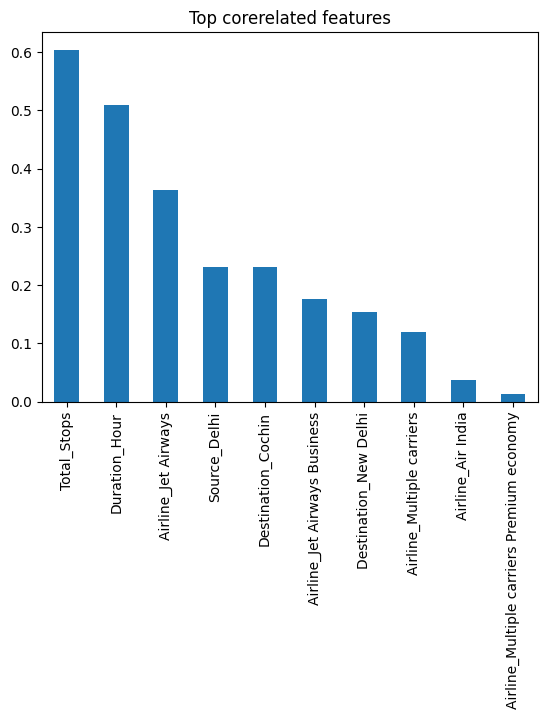

In [ ]:
top_corr=price_corr.drop('Price').head(10)# Here we temp drop price to plot graph. We did nor drop permanantly.
top_corr.plot(kind='bar',title="Top corerelated features")

In [62]:
price_corr[price_corr.index.str.contains('Airline')].sort_values()

Airline_IndiGo                              -0.311540
Airline_SpiceJet                            -0.260683
Airline_Air Asia                            -0.105233
Airline_GoAir                               -0.070114
Airline_Vistara                             -0.051849
Airline_Trujet                              -0.010380
Airline_Vistara Premium economy             -0.000453
Airline_Multiple carriers Premium economy    0.012469
Airline_Air India                            0.037083
Airline_Multiple carriers                    0.119560
Airline_Jet Airways Business                 0.176152
Airline_Jet Airways                          0.362757
Name: Price, dtype: float64

In [64]:
price_corr[price_corr.index.str.contains('Airline')].sort_values()

Airline_IndiGo                              -0.311540
Airline_SpiceJet                            -0.260683
Airline_Air Asia                            -0.105233
Airline_GoAir                               -0.070114
Airline_Vistara                             -0.051849
Airline_Trujet                              -0.010380
Airline_Vistara Premium economy             -0.000453
Airline_Multiple carriers Premium economy    0.012469
Airline_Air India                            0.037083
Airline_Multiple carriers                    0.119560
Airline_Jet Airways Business                 0.176152
Airline_Jet Airways                          0.362757
Name: Price, dtype: float64

In [65]:
price_corr[price_corr.index.str.contains('Source')]

Source_Delhi       0.230339
Source_Kolkata     0.009067
Source_Banglore   -0.103585
Source_Chennai    -0.156199
Source_Mumbai     -0.190430
Name: Price, dtype: float64

In [66]:
price_corr[price_corr.index.str.contains('Destination')]

Destination_Cochin       0.230339
Destination_New Delhi    0.154426
Destination_Banglore     0.009067
Destination_Kolkata     -0.156199
Destination_Hyderabad   -0.190430
Destination_Delhi       -0.264454
Name: Price, dtype: float64

Feature selection

DEcide which feature to keep ->haev meaning,have some reltionship with price

In [67]:
price_corr

Price                                        1.000000
Total_Stops                                  0.603898
Duration_Hour                                0.508802
Airline_Jet Airways                          0.362757
Source_Delhi                                 0.230339
Destination_Cochin                           0.230339
Airline_Jet Airways Business                 0.176152
Destination_New Delhi                        0.154426
Airline_Multiple carriers                    0.119560
Airline_Air India                            0.037083
Airline_Multiple carriers Premium economy    0.012469
Destination_Banglore                         0.009067
Source_Kolkata                               0.009067
Dept_Hour                                    0.006823
Airline_Vistara Premium economy             -0.000453
Airline_Trujet                              -0.010380
Dept_Min                                    -0.024549
Airline_Vistara                             -0.051849
Airline_GoAir               

In [68]:
price_corr.index

Index(['Price', 'Total_Stops', 'Duration_Hour', 'Airline_Jet Airways',
       'Source_Delhi', 'Destination_Cochin', 'Airline_Jet Airways Business',
       'Destination_New Delhi', 'Airline_Multiple carriers',
       'Airline_Air India', 'Airline_Multiple carriers Premium economy',
       'Destination_Banglore', 'Source_Kolkata', 'Dept_Hour',
       'Airline_Vistara Premium economy', 'Airline_Trujet', 'Dept_Min',
       'Airline_Vistara', 'Airline_GoAir', 'Source_Banglore', 'Journey_Month',
       'Airline_Air Asia', 'Duration_mins', 'Journey_Day',
       'Destination_Kolkata', 'Source_Chennai', 'Destination_Hyderabad',
       'Source_Mumbai', 'Airline_SpiceJet', 'Destination_Delhi',
       'Airline_IndiGo'],
      dtype='str')

In [118]:
#select the features with threshold value

selected_features=price_corr[price_corr>0.15].index

In [119]:
selected_features

Index(['Price', 'Total_Stops', 'Duration_Hour', 'Airline_Jet Airways',
       'Source_Delhi', 'Destination_Cochin', 'Airline_Jet Airways Business',
       'Destination_New Delhi'],
      dtype='str')

In [ ]:
#Here we will drop the price permauntly
selected_features=selected_features.drop('Price')

In [121]:
selected_features

Index(['Total_Stops', 'Duration_Hour', 'Airline_Jet Airways', 'Source_Delhi',
       'Destination_Cochin', 'Airline_Jet Airways Business',
       'Destination_New Delhi'],
      dtype='str')

In [122]:
X=flight_df[selected_features]

In [123]:
X

,Total_Stops,Duration_Hour,Airline_Jet Airways,Source_Delhi,Destination_Cochin,Airline_Jet Airways Business,Destination_New Delhi
0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
1,2.0,7.0,0.0,0.0,0.0,0.0,0.0
2,2.0,19.0,1.0,1.0,1.0,0.0,0.0
3,1.0,5.0,0.0,0.0,0.0,0.0,0.0
4,1.0,4.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
10677,0.0,2.0,0.0,0.0,0.0,0.0,0.0
10678,0.0,2.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,2.0,1.0,0.0,0.0,0.0,0.0
10680,0.0,3.0,0.0,0.0,0.0,0.0,1.0


In [124]:
y=flight_df['Price']

In [125]:
y

0         3897.0
1         7662.0
2        13882.0
3         6218.0
4        13302.0
          ...   
10677     3257.0
10678     4107.0
10679     4145.0
10680     7229.0
10681    12648.0
Name: Price, Length: 10681, dtype: float64

In [126]:
import numpy as np
np.random.seed(42)
np.random.random()

0.3745401188473625

In [127]:
#ML model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#what is my x--selected features
#what is my y-->price

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [128]:
X_train

,Total_Stops,Duration_Hour,Airline_Jet Airways,Source_Delhi,Destination_Cochin,Airline_Jet Airways Business,Destination_New Delhi
10610,0.0,2.0,1.0,0.0,0.0,0.0,0.0
1034,1.0,6.0,0.0,1.0,1.0,0.0,0.0
8122,0.0,2.0,0.0,0.0,0.0,0.0,1.0
4779,1.0,11.0,1.0,0.0,0.0,0.0,0.0
3207,1.0,5.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
5734,1.0,19.0,1.0,1.0,1.0,0.0,0.0
5191,1.0,6.0,1.0,0.0,0.0,0.0,0.0
5390,1.0,12.0,0.0,1.0,1.0,0.0,0.0
860,0.0,2.0,0.0,0.0,0.0,0.0,1.0


In [129]:
X_test

,Total_Stops,Duration_Hour,Airline_Jet Airways,Source_Delhi,Destination_Cochin,Airline_Jet Airways Business,Destination_New Delhi
4830,1.0,4.0,0.0,0.0,0.0,0.0,0.0
3771,1.0,11.0,0.0,0.0,0.0,0.0,0.0
1523,1.0,24.0,1.0,1.0,1.0,0.0,0.0
3393,1.0,11.0,1.0,1.0,1.0,0.0,0.0
4169,0.0,3.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
9870,1.0,19.0,0.0,0.0,0.0,0.0,0.0
10062,2.0,7.0,0.0,1.0,1.0,0.0,0.0
6911,0.0,2.0,0.0,0.0,0.0,0.0,0.0
8616,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [130]:
y_train

10610     3597.0
1034      5583.0
8122     10873.0
4779     12681.0
3207      6218.0
          ...   
5734     12242.0
5191     10844.0
5390      7670.0
860       6144.0
7270     10262.0
Name: Price, Length: 8544, dtype: float64

In [131]:
y_test

4830      7476.0
3771      7927.0
1523      5963.0
3393     16289.0
4169      8016.0
          ...   
9870     13044.0
10062    18804.0
6911      4668.0
8616      2017.0
8988      9836.0
Name: Price, Length: 2137, dtype: float64

In [132]:
lr=LinearRegression()#y=mx+c(maths)-->y=b+w1x1+w2x2+w3x3+w4x4+w5x5+w6x6+w7x7+w8x8
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [133]:
y_pred=lr.predict(X_test)

In [134]:
y_pred

array([ 8089.13176407,  8401.09168576, 11843.71407847, ...,
        4734.64878064,  4690.08307755, 12379.49451257], shape=(2137,))

In [135]:
y_test

4830      7476.0
3771      7927.0
1523      5963.0
3393     16289.0
4169      8016.0
          ...   
9870     13044.0
10062    18804.0
6911      4668.0
8616      2017.0
8988      9836.0
Name: Price, Length: 2137, dtype: float64

In [136]:
#evalution
from sklearn.metrics import mean_absolute_error
lr_mae=mean_absolute_error(y_test,y_pred)#1/n summation ytest-ypred

In [137]:
lr_mae

2239.665424160137

In [138]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error  

In [139]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Decision Tree": DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=20,
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}


In [140]:
models.items()

dict_items([('Linear Regression', LinearRegression()), ('Decision Tree', DecisionTreeRegressor(max_depth=20, min_samples_leaf=20, random_state=42)), ('Random Forest', RandomForestRegressor(random_state=42))])

In [141]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append([name, r2, mae])

In [142]:
results

[['Linear Regression', 0.4587395829557088, 2239.665424160137],
 ['Decision Tree', 0.5511571458402744, 2047.2486625135016],
 ['Random Forest', 0.5350754628260386, 2063.712347275402]]

In [143]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE"]
)

results_df

,Model,R2 Score,MAE
0,Linear Regression,0.458740,2239.665424
1,Decision Tree,0.551157,2047.248663
2,Random Forest,0.535075,2063.712347


In [144]:
from sklearn.ensemble import ExtraTreesRegressor
etr = ExtraTreesRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42
)

etr.fit(X_train, y_train)

y_pred_etr = etr.predict(X_test)

print("Extra Trees R2:", r2_score(y_test, y_pred_etr))
print("Extra Trees MAE:", mean_absolute_error(y_test, y_pred_etr))

Extra Trees R2: 0.5480747147534801
Extra Trees MAE: 2047.8717824906628


In [145]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("GBR R2:", r2_score(y_test, y_pred_gbr))
print("GBR MAE:", mean_absolute_error(y_test, y_pred_gbr))

GBR R2: 0.5605622479666208
GBR MAE: 2032.932991713428


1.linear Regression--2292 error 2.Deciison Tree Regressor--2102 error 3.Random forest Regressor--2091 error 4.Extra Tree Regerssor--2088 error 5.Gradient Boosting Regressor--2088 error

1. linear Regression--2239 error
2. Deciison Tree Regressior--2047 error
3. Random forest Regressior--2063
4. Extra Tree Regressior -- 20247
5. Gradient Boosting Regressor--2032 error #This has less error so pick this Algoritham